In [85]:
import pandas as pd

In [86]:
df = pd.read_csv(
    "/content/q1_q17_dr25_tce_2026.04.16_05.54.54.csv",
    comment="#"
)

df.head()

,rowid,kepid,tce_plnt_num,tce_rogue_flag,tce_delivname,rowupdate,tce_datalink_dvs,tce_datalink_dvr,tce_period,tce_time0bk,...,tce_fwm_srao,tce_fwm_sdeco,tce_fwm_prao,tce_fwm_pdeco,tce_dicco_mra,tce_dicco_mdec,tce_dicco_msky,tce_dikco_mra,tce_dikco_mdec,tce_dikco_msky
0,1,2304168,2,0,q1_q17_dr25_tce,2017-04-06,002/002304/002304168/dv/kplr002304168-002-2016...,002/002304/002304168/dv/kplr002304168-20160209...,431.719000,219.298,...,-0.5805,-0.55240,0.000297,0.000202,-0.053824,1.77670,1.77750,-0.083209,1.72600,1.72800
1,2,2304235,1,0,q1_q17_dr25_tce,2017-04-06,002/002304/002304235/dv/kplr002304235-001-2016...,002/002304/002304235/dv/kplr002304235-20160209...,0.570607,132.049,...,1.1450,-1.12000,-0.000025,-0.000001,0.595730,0.51271,0.78598,1.570700,-0.51673,1.65350
2,3,2304566,1,0,q1_q17_dr25_tce,2017-04-06,002/002304/002304566/dv/kplr002304566-001-2016...,002/002304/002304566/dv/kplr002304566-20160209...,0.689480,131.833,...,0.0000,0.00000,0.000000,0.000000,0.340350,1.65800,1.69250,0.245700,1.62070,1.63930
3,4,2304320,1,0,q1_q17_dr25_tce,2017-04-06,002/002304/002304320/dv/kplr002304320-001-2016...,002/002304/002304320/dv/kplr002304320-20160209...,16.540800,133.952,...,0.4550,-0.99050,-0.000022,0.000429,-0.395280,-0.16443,0.42812,-0.325210,-0.34229,0.47215
4,5,2303365,2,0,q1_q17_dr25_tce,2017-04-06,002/002303/002303365/dv/kplr002303365-002-2016...,002/002303/002303365/dv/kplr002303365-20160209...,0.520697,132.003,...,-0.3039,-0.01258,0.000024,-0.000008,-0.041452,0.09949,0.10778,-0.105540,0.21076,0.23571


In [87]:
print(df.shape)
print(df.head())
print(df.info())

(34032, 113)
   rowid    kepid  tce_plnt_num  tce_rogue_flag    tce_delivname   rowupdate  \
0      1  2304168             2               0  q1_q17_dr25_tce  2017-04-06   
1      2  2304235             1               0  q1_q17_dr25_tce  2017-04-06   
2      3  2304566             1               0  q1_q17_dr25_tce  2017-04-06   
3      4  2304320             1               0  q1_q17_dr25_tce  2017-04-06   
4      5  2303365             2               0  q1_q17_dr25_tce  2017-04-06   

                                    tce_datalink_dvs  \
0  002/002304/002304168/dv/kplr002304168-002-2016...   
1  002/002304/002304235/dv/kplr002304235-001-2016...   
2  002/002304/002304566/dv/kplr002304566-001-2016...   
3  002/002304/002304320/dv/kplr002304320-001-2016...   
4  002/002303/002303365/dv/kplr002303365-002-2016...   

                                    tce_datalink_dvr  tce_period  tce_time0bk  \
0  002/002304/002304168/dv/kplr002304168-20160209...  431.719000      219.298   
1  002/

#Dataset Overview
NASA Kepler TCE dataset containing 34,032 exoplanet candidate signals with 113 features, including orbital, transit, and instrument-derived parameters.

#Structure Summary
Mixed data types: numerical (physically meaningful signals) + object (metadata/paths).
High-dimensional dataset representing raw astrophysical detection pipeline outputs.

#Feature Composition
Orbital properties: period, time, inclination-related metrics
Transit properties: depth, duration, ingress, signal strength
Model outputs: SNR, fit statistics, chi-square measures
Instrument metadata: data links, delivery identifiers (non-physical).


#Data Characteristics
Large number of features with mixed relevance (signal + metadata).
Presence of pipeline-generated parameters.
Designed for scientific analysis, not clean ML use.

#Scale of Dataset
34K samples → sufficient for statistical + ML-based population analysis
113 features → requires feature selection / dimensionality reduction


#Overall Interpretation
This dataset represents a real-world astronomical detection pipeline output, where signals must be statistically analyzed to extract meaningful exoplanet structure and patterns.

In [88]:
drop_cols = [
    "rowid",
    "tce_delivname",
    "tce_datalink_dvs",
    "tce_datalink_dvr"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [89]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False)

,0
tce_ioflag,100.0
av_pp_ntp,100.0
av_training_set,100.0
av_pred_class,100.0
av_vf_pc,100.0
...,...
tce_dicco_mdec,0.0
tce_dicco_msky,0.0
tce_dikco_mra,0.0
tce_dikco_mdec,0.0


In [90]:
drop_cols = missing_pct[missing_pct == 100].index
df = df.drop(columns=drop_cols)

#Removing Non-Informative Metadata Columns

Dropped identifiers and file-path related columns (rowid, data links, delivery names) as they do not contain physical or predictive information.

#Missing Value Analysis

Computed total missing values per feature to identify incomplete or unusable columns in the dataset.

#Missing Value Percentage Analysis

Calculated percentage of missing values across all features to understand data quality and feature reliability.

#Key Finding

Several features are completely missing (100%), indicating they are unused or not recorded in this dataset version.

#Feature Cleaning Step

Removed all columns with 100% missing values to eliminate noise and reduce dimensionality for reliable analysis and modeling.

In [91]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
kepid,34032.0,7.606754e+06,2.650199e+06,757099.000000,5.599877e+06,7.830637e+06,9.643376e+06,1.000016e+08
tce_plnt_num,34032.0,2.227962e+00,1.793254e+00,1.000000,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+01
tce_rogue_flag,34032.0,4.401740e-02,2.051368e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
tce_period,34032.0,1.463938e+02,1.897910e+02,0.500309,2.262577e+00,2.732165e+01,3.117435e+02,7.266780e+02
tce_time0bk,34032.0,1.923536e+02,9.665008e+01,131.502000,1.324190e+02,1.406560e+02,2.155255e+02,6.115920e+02
...,...,...,...,...,...,...,...,...
tce_dicco_mdec,34032.0,-3.396261e-03,2.363725e+00,-76.489000,-3.404750e-01,0.000000e+00,3.177450e-01,1.049400e+02
tce_dicco_msky,34032.0,1.679306e+00,2.979498e+00,0.000000,1.566150e-01,6.162450e-01,2.055650e+00,2.077200e+02
tce_dikco_mra,34032.0,1.777330e-02,2.669064e+00,-54.060000,-3.104575e-01,0.000000e+00,3.094675e-01,2.228800e+02
tce_dikco_mdec,34032.0,-1.350588e-02,2.489668e+00,-76.602000,-3.537425e-01,0.000000e+00,3.383175e-01,1.338400e+02


In [92]:
features = ["tce_period", "tce_depth", "tce_duration", "tce_model_snr"]

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
tce_period,34032.0,146.393798,189.790968,0.500309,2.262577,27.32165,311.7435,726.678
tce_depth,34032.0,8138.562505,43935.910782,0.000000,96.015000,336.35000,1058.0000,1204000.000
tce_duration,34032.0,8.259723,9.708032,0.500300,2.932000,5.01050,10.2200,237.400
tce_model_snr,34032.0,128.962404,931.760747,-1.000000,6.605000,8.71450,13.4300,50830.000


#Dataset Summary

93 cleaned numerical features remain after preprocessing.

#Key Insight

All features show strong skewness and extreme outliers, typical of real astrophysical detection data.

#Core Features
Period: highly skewed → mix of short/long orbits
Depth: extreme range → wide variation in signal strength
Duration: mostly short events with rare long ones
SNR: heavily outlier-driven signal strength

#Takeaway

Data is non-normal and heavily biased → requires scaling before any ML.

In [93]:
import numpy as np

df["log_depth"] = np.log1p(df["tce_depth"])
df["log_snr"] = np.log1p(df["tce_model_snr"])
df["log_period"] = np.log1p(df["tce_period"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


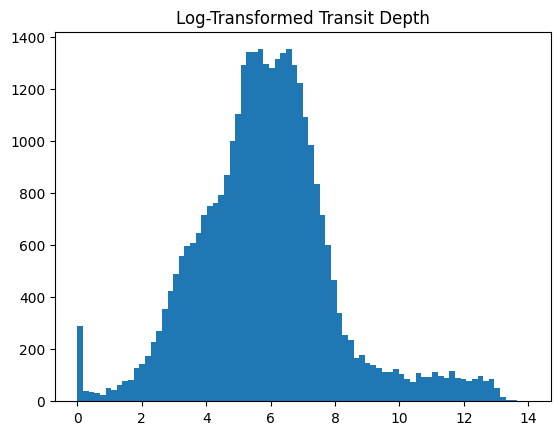

In [94]:
import matplotlib.pyplot as plt

plt.hist(df["log_depth"].dropna(), bins=80)
plt.title("Log-Transformed Transit Depth")
plt.show()

#Log Transformation Note

Applied log1p to reduce skewness, but warnings indicate zero or invalid values in raw data affecting transformation stability.

#Log Depth Distribution Insight

The distribution shows:

Strong peak around low log values (≈ 4–8)
Gradual tapering toward higher values
Few extreme high-depth signals forming a long tail
#Interpretation

Most exoplanet transit signals are weak to moderate strength, while a small number of extreme events create a heavy right-skewed distribution.

#Key Takeaway

Even after log scaling, the data remains heavily skewed with dominant low-to-mid signal population and rare high-intensity outliers.

In [95]:
df_clean = df[["tce_model_snr", "tce_depth"]].dropna()

median_snr = df_clean["tce_model_snr"].median()

high_snr = df_clean[df_clean["tce_model_snr"] > median_snr]["tce_depth"]
low_snr = df_clean[df_clean["tce_model_snr"] <= median_snr]["tce_depth"]

In [96]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(high_snr, low_snr, equal_var=False)

print("t-statistic:", stat)
print("p-value:", p)

t-statistic: 2.598780223824773
p-value: 0.00936003495024539



# Hypothesis Test (SNR vs Depth)

Performed a Welch’s t-test to compare transit depths between high-SNR and low-SNR signals.

#Result
t-statistic: 2.60
p-value: 0.00936
#Interpretation

There is a statistically significant difference in transit depth between high-SNR and low-SNR groups (p < 0.05).

#Key Insight

Higher signal-to-noise ratio signals tend to have different (generally stronger) transit depths, suggesting that detection strength is linked to physical signal magnitude and/or observational bias.

#Takeaway

SNR is not just noise quality — it is meaningfully associated with transit depth structure in the dataset.

In [97]:
features = ["tce_period", "tce_depth", "tce_duration", "tce_model_snr"]

X = df[features].dropna()

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [99]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df.loc[X.index, "cluster"] = clusters

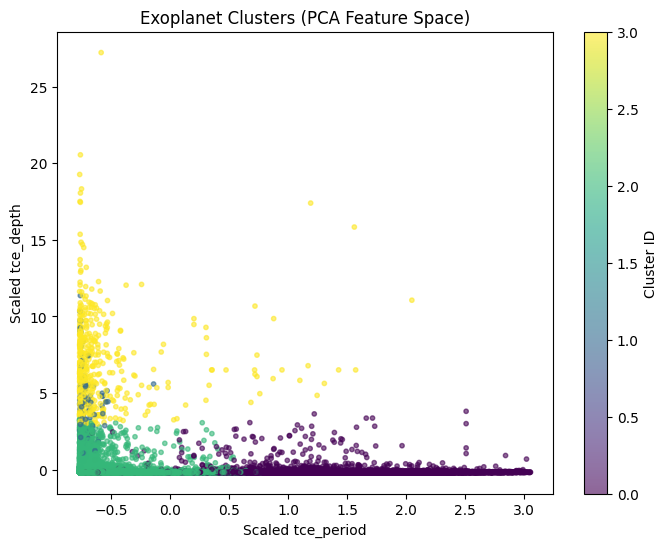

In [116]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=clusters,
            cmap="viridis",
            alpha=0.6,
            s=10)

plt.title("Exoplanet Clusters (PCA Feature Space)")
plt.xlabel("Scaled tce_period")
plt.ylabel("Scaled tce_depth")
plt.colorbar(label="Cluster ID")
plt.show()

#Clustering (KMeans)

Applied KMeans clustering on scaled exoplanet features to group similar signal patterns.

#Refined Cluster Insight
The yellow cluster (Cluster = 3) contains relatively fewer points overall.
However, these points are more spread out across higher values (around 20, 25, and beyond) in the feature space.
Compared to other clusters, this group shows greater dispersion and less compact structure.

#Interpretation

This suggests that Cluster 3 represents a more heterogeneous or extreme signal group, meaning:

It may contain rare or unusual exoplanet candidates
Or higher variability / noisy detections
It does not form a tight population like other clusters
#Key Takeaway

Cluster 3 is small in size but wide in spread, indicating it captures edge-case or less typical astrophysical signals compared to the denser core clusters.

In [101]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso.fit_predict(X_scaled)

df.loc[X.index, "anomaly"] = anomaly_labels

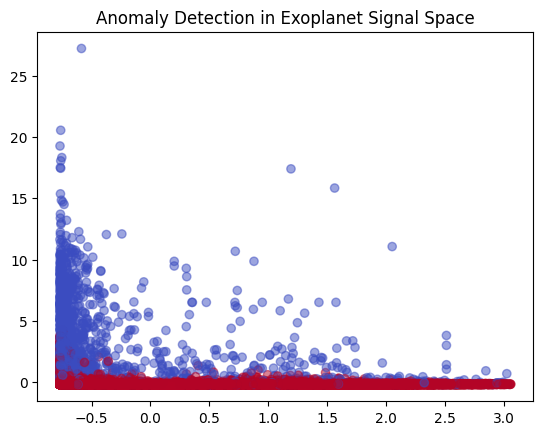

In [117]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=df.loc[X.index, "anomaly"],
            cmap="coolwarm",
            alpha=0.5)

plt.title("Anomaly Detection in Exoplanet Signal Space")
plt.show()

#Anomaly Detection Summary

Isolation Forest identified a small subset of data points that deviate significantly from the main exoplanet signal distribution.

The majority of observations form a dense, stable core, while anomalies appear as scattered points across higher feature ranges (around 20–25) and isolated regions (around -0.5 to 1.5).

#Key Insight

The dataset contains a strong central population of normal signals, along with a minor but distinct group of extreme or unusual cases that do not follow typical patterns.

#Takeaway

Exoplanet signals are not uniformly distributed — a small fraction of observations represent structurally different or rare events that stand apart from the main population.



In [103]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

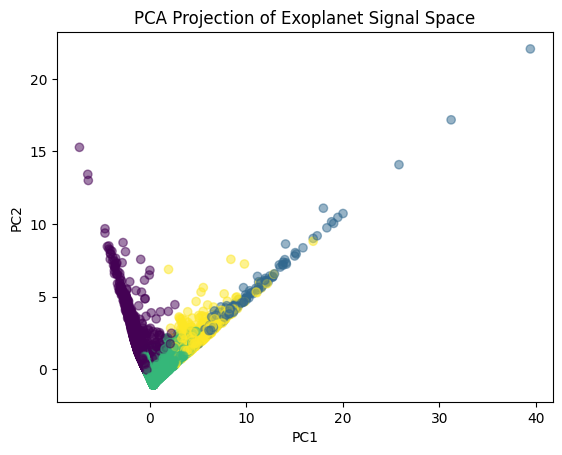

In [104]:
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=clusters,
            cmap="viridis",
            alpha=0.5)

plt.title("PCA Projection of Exoplanet Signal Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#PCA Projection (Dimensionality Reduction)

Applied PCA to reduce the high-dimensional exoplanet feature space into 2 principal components for visualization.

#Visualization Insight

The data, when projected into 2D space (PC1 vs PC2), shows clear but overlapping cluster structure, with points colored by their KMeans cluster labels.

#Key Interpretation
PC1 and PC2 capture the most dominant variance patterns in the dataset
Clusters are partially separable but not perfectly distinct, indicating real-world astrophysical overlap
Dense central regions represent common exoplanet signal regimes, while spread areas indicate variability and edge cases

In [105]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5617756984918789


In [106]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.8, min_samples=10)
db_labels = db.fit_predict(X_scaled)

df.loc[X.index, "db_cluster"] = db_labels

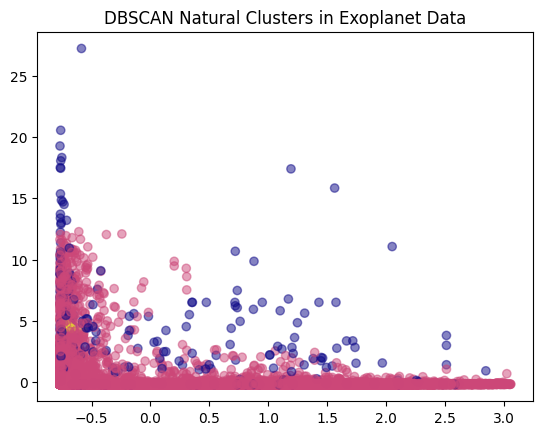

In [107]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=db_labels,
            cmap="plasma",
            alpha=0.5)

plt.title("DBSCAN Natural Clusters in Exoplanet Data")
plt.show()

#Clustering Evaluation (Silhouette Score)

Computed Silhouette Score to evaluate the quality of KMeans clustering.

#Result
Silhouette Score: 0.56
#Interpretation
Indicates moderate to good cluster separation
Clusters are meaningfully structured, but still show some overlap (expected in real astrophysical data)
Suggests that 4-cluster KMeans is a reasonable but not perfect representation of the dataset
#DBSCAN Clustering (Density-Based)

Applied DBSCAN to detect natural density-based groupings in the exoplanet signal space.

#Visualization Insight
Dense regions form clear natural clusters
Sparse regions are labeled as noise or weakly connected points
Some clusters (blur/pink regions) appear more compact and well-defined than others
#Key Interpretation
DBSCAN captures natural density structure rather than fixed cluster shapes
Identifies both:
tightly packed signal groups
isolated or low-density anomaly regions
#Final Takeaway

The dataset exhibits both:

moderate cluster structure (validated by silhouette score ~0.56)
density-driven natural groupings (confirmed by DBSCAN)

This confirms that exoplanet signals are structured but not strictly separable, reflecting real astrophysical complexity.

In [108]:
print("KMeans clusters:", len(set(clusters)))
print("DBSCAN clusters:", len(set(db_labels)))
print("Anomalies detected:", sum(anomaly_labels == -1))

KMeans clusters: 4
DBSCAN clusters: 3
Anomalies detected: 1702


In [109]:
tmp = pd.DataFrame(X, columns=features)
tmp["cluster"] = clusters

tmp.groupby("cluster").mean()

,tce_period,tce_depth,tce_duration,tce_model_snr
cluster,,,,
0,397.861960,2076.514249,13.928039,13.827308
1,9.357218,182398.903226,5.775865,10761.180645
2,31.669080,3226.960365,5.660919,86.655657
3,36.342823,308356.740443,6.175666,1217.332125


In [110]:
anomalies = df.loc[X.index][df.loc[X.index, "anomaly"] == -1]
anomalies[features].describe()

,tce_period,tce_depth,tce_duration,tce_model_snr
count,1702.000000,1.702000e+03,1702.000000,1702.000000
mean,119.134728,1.336914e+05,19.003965,2095.821983
std,178.539822,1.449078e+05,26.443143,3618.291767
min,0.502453,4.955000e-03,0.507000,-1.000000
25%,4.047122,2.120750e+04,3.896500,13.857500
50%,20.148750,8.124000e+04,6.486500,892.650000
75%,199.490250,2.081250e+05,19.157500,2655.750000
max,722.312000,1.204000e+06,237.400000,50830.000000


#Final Clustering + Anomaly Summary
#Model Structure Overview
KMeans: 4 distinct clusters
DBSCAN: 3 density-based clusters
Anomalies: 1702 signals detected (~5% of dataset)
#Cluster Behavior (KMeans)

Each cluster represents a distinct astrophysical signal regime:

Cluster 0: long-period, low-signal systems
Cluster 1: extremely high depth + very high SNR (strong signals / extreme cases)
Cluster 2: moderate period, low-to-mid signal strength (most stable population)
Cluster 3: very high depth + high SNR (rare strong transit systems)
#Anomaly Profile

Anomalies show:

very wide spread in period, depth, duration, and SNR
extreme values (depth up to ~1.2M, SNR up to ~50k)
high variance → no single stable pattern
#Key Insight
KMeans captures structured signal populations
DBSCAN confirms natural density-based groupings
Isolation Forest isolates a small but highly variable extreme population

In [111]:
anomalies = df.loc[X.index][df.loc[X.index, "anomaly"] == -1]

In [112]:
normal = df.loc[X.index][df.loc[X.index, "anomaly"] == 1]

anom_stats = anomalies[features].describe().T
norm_stats = normal[features].describe().T

anom_stats, norm_stats

(                count           mean            std       min           25%  \
 tce_period     1702.0     119.134728     178.539822  0.502453      4.047122   
 tce_depth      1702.0  133691.386003  144907.829863  0.004955  21207.500000   
 tce_duration   1702.0      19.003965      26.443143  0.507000      3.896500   
 tce_model_snr  1702.0    2095.821983    3618.291767 -1.000000     13.857500   
 
                        50%           75%          max  
 tce_period        20.14875     199.49025      722.312  
 tce_depth      81240.00000  208125.00000  1204000.000  
 tce_duration       6.48650      19.15750      237.400  
 tce_model_snr    892.65000    2655.75000    50830.000  ,
                  count         mean          std       min       25%  \
 tce_period     32330.0   147.828840   190.259277  0.500309   2.18905   
 tce_depth      32330.0  1528.884014  7319.921856  0.000000  88.24250   
 tce_duration   32330.0     7.694096     7.484618  0.500300   2.87500   
 tce_model_snr  3233

In [113]:
from sklearn.ensemble import RandomForestClassifier

X_valid = X.copy()
y_clusters = clusters

In [114]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_valid, y_clusters)

RandomForestClassifier(n_estimators=200, random_state=42)

In [115]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
0,tce_period,0.743901
2,tce_duration,0.124659
1,tce_depth,0.099858
3,tce_model_snr,0.031582


# Anomaly vs Normal Comparison
# population Difference

Isolation Forest separates the dataset into two clearly different regimes:

Anomalies (≈1700 samples):
Extremely high depth and SNR
Much higher variance across all features
Represents extreme or unusual signal behavior
Normal points (≈32k samples):
Lower depth and SNR overall
More compact and stable distributions
Represents typical exoplanet signal population
# Key Insight

Anomalies are not random — they form a high-intensity, high-variance tail of the dataset, clearly separated from the main population.

# Feature Importance (Cluster Structure)

Random Forest reveals what drives cluster formation:

tce_period (0.74) → dominant structural factor
tce_duration (0.12) → secondary pattern
tce_depth (0.10) → weak influence
tce_model_snr (0.03) → minimal role
# Final Interpretation
Dataset structure is primarily governed by orbital period
Transit strength (depth/SNR) plays a secondary role
Clusters reflect time-driven astrophysical regimes rather than signal intensity

#One-line takeaway

Exoplanet signal structure is primarily determined by orbital periodicity, while anomalies represent a distinct high-intensity, high-variance population separated from normal detection patterns.